# Mini Backtest Lab — Time-Series Momentum & Mean Reversion (ETFs)

**Goal.** Compare two simple, interpretable strategies on liquid ETFs using a clean research loop:
data → signals → weights → PnL (no lookahead) → costs → performance & risk metrics → sensitivity.

**Universe.** SPY, QQQ, IWM, TLT, GLD (daily).  
**Key safeguards.** Lagged weights (t−1), transaction costs via turnover, baselines, sensitivity checks.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from qmlab.data import load_prices_yf, compute_returns
from qmlab.backtest import signal_tsmom, signal_meanrev, signal_to_weights, backtest
from qmlab.metrics import summarize_performance, equity_curve, drawdown_series, turnover

tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD"]
start, end = "2015-01-01", "2025-01-01"

## 1. Data

- Source: Yahoo Finance (`Adj Close`)
- Period: 2015–2025
- Returns: **simple returns** (pct change)
- Light cleaning: forward-fill limited to small gaps; drop rows with all missing values.

In [28]:
prices = load_prices_yf(tickers, start=start, end=end)
rets = compute_returns(prices, kind="simple")

data_summary = pd.DataFrame({
    "start": [prices.index.min()],
    "end": [prices.index.max()],
    "n_days": [len(prices)],
    "missing_%": [float(prices.isna().mean().mean() * 100)],
})
data_summary

,start,end,n_days,missing_%
0,2015-01-02,2024-12-31,2516,0.0


**Dataset check.** We use daily adjusted close prices for SPY, QQQ, IWM, TLT, and GLD from 2015-01-02 to 2024-12-31 (2516 trading days). The download is complete (0% missing values), so results are not driven by imputation or data gaps.

## 2. Strategy definitions

### Time-Series Momentum (TSMOM)
- Compute score as rolling sum of `log(1 + r)` over lookback L
- Signal = `sign(score)` in {−1, 0, +1}
- Weights: equal-weight across active positions (gross exposure ≈ 1)

### Mean Reversion (MR)
- Rolling z-score based on rolling sum and rolling std over lookback L
- Enter when |z| > z_entry, signal = −sign(z)

### Execution / bias control
- Portfolio uses **weights shifted by 1 day** (t−1) to avoid lookahead.
- Transaction costs: `cost_bps × turnover`, applied with a one-day lag.

In [38]:
def run_strategy(rets, kind="tsmom", lookback=60, cost_bps=5.0, z_entry=1.0):
    if kind == "tsmom":
        sig = signal_tsmom(rets, lookback=lookback)
    elif kind == "meanrev":
        sig = signal_meanrev(rets, lookback=lookback, z_entry=z_entry)
    else:
        raise ValueError("kind must be 'tsmom' or 'meanrev'")

    w = signal_to_weights(sig)
    rp = backtest(rets, w, cost_bps=cost_bps)
    return rp, w

rp_mom, w_mom = run_strategy(rets, kind="tsmom", lookback=60, cost_bps=5.0)
rp_mr,  w_mr  = run_strategy(rets, kind="meanrev", lookback=20, cost_bps=5.0, z_entry=1.0)

### Experiment settings (baseline run)

We report the main results for the following parameter choices:
- TSMOM: lookback L = 60, cost = 5 bps
- Mean Reversion: lookback L = 20, z_entry = 1.0, cost = 5 bps

In [48]:
settings = pd.DataFrame([
    {"strategy": "TSMOM", "L": 60, "z_entry": np.nan, "cost_bps": 5},
    {"strategy": "MeanRev", "L": 20, "z_entry": 1.0, "cost_bps": 5},
])
settings

,strategy,L,z_entry,cost_bps
0,TSMOM,60,NaN,5
1,MeanRev,20,1.0,5


## 3. Evaluation metrics

We report:
- Annualized return (geometric)
- Annualized volatility
- Sharpe (rf=0)
- Max drawdown
- Average turnover (proxy for cost sensitivity)

In [49]:
def metrics_row(name, rp, w):
    m = summarize_performance(rp)
    m["avg_turnover"] = float(turnover(w).mean())
    m["name"] = name
    return m

tbl_main = pd.DataFrame([
    metrics_row("TSMOM (L=60, cost=5bps)", rp_mom, w_mom),
    metrics_row("MeanRev (L=20, z=1.0, cost=5bps)", rp_mr, w_mr),
]).set_index("name")

tbl_main.round(4)

,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover
name,,,,,
"TSMOM (L=60, cost=5bps)",0.0118,0.1175,0.159,-0.1776,0.0957
"MeanRev (L=20, z=1.0, cost=5bps)",-0.1051,0.1454,-0.691,-0.7192,0.4213


## 4. Main results (baseline parameter choices)

We evaluate two simple strategies on SPY/QQQ/IWM/TLT/GLD with daily data (2015–2024), using lagged weights (t−1) to avoid lookahead and applying transaction costs proportional to turnover (5 bps).

- **TSMOM (L=60)** delivers a small but positive performance: annualized return ≈ **1.2%**, volatility ≈ **11.7%**, Sharpe ≈ **0.16**, and max drawdown ≈ **−17.8%**. Turnover is moderate (≈ **0.10**), suggesting costs are not the main issue; rather, the raw signal strength is limited in this simple equal-weight implementation.
- **Mean Reversion (L=20, z=1.0)** performs poorly: annualized return ≈ **−10.5%**, Sharpe ≈ **−0.69**, and a very large max drawdown (≈ **−72%**). Turnover is high (≈ **0.42**), making the strategy highly sensitive to even mild costs and indicating an unstable/noisy signal in this setup.

Overall, the momentum specification is “survivable” but weak, while the mean-reversion specification is dominated by turnover and adverse regime exposure.

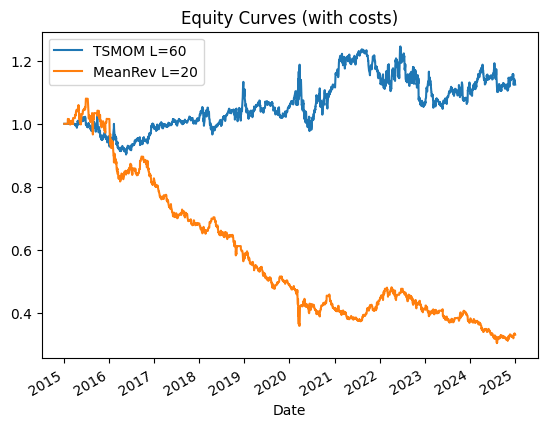

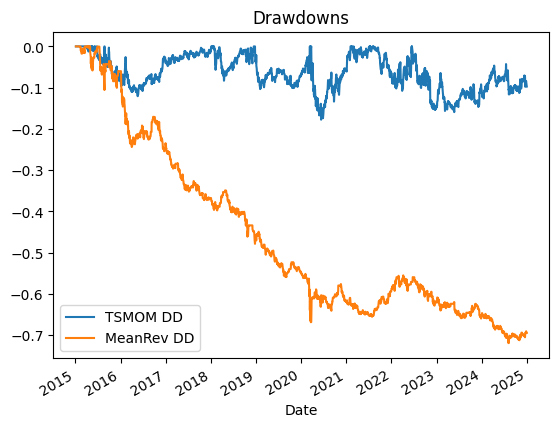

In [40]:
plt.figure()
equity_curve(rp_mom).plot(label="TSMOM L=60")
equity_curve(rp_mr).plot(label="MeanRev L=20")
plt.title("Equity Curves (with costs)")
plt.legend()
plt.show()

plt.figure()
drawdown_series(rp_mom).plot(label="TSMOM DD")
drawdown_series(rp_mr).plot(label="MeanRev DD")
plt.title("Drawdowns")
plt.legend()
plt.show()

## 5. Results (equity curves and drawdowns)

**TSMOM (L=60, 5 bps).** The strategy produces a small but positive long-run drift with moderate drawdowns. Performance is regime-dependent: it benefits during strong trending periods (notably around 2020–2021), but experiences choppy, low-Sharpe behavior in range/whipsaw regimes (e.g., parts of 2015–2016 and 2022–2024). The drawdown profile remains contained (max drawdown ≈ −18%), consistent with moderate turnover.

**Mean Reversion (L=20, z=1.0, 5 bps).** The strategy exhibits persistent underperformance with a near-monotonic equity decay and very large drawdowns (≈ −70%). High turnover makes the approach extremely sensitive to costs, and the PnL profile suggests an unstable/noisy signal that is structurally misaligned with the prevailing trend dynamics of the ETF universe.

## 6. Baselines

We add simple baselines to contextualize results:
- Equal-weight portfolio (rebalanced daily, 1/N)
- SPY buy-and-hold

In [ ]:
w_eq = pd.DataFrame(1/len(tickers), index=rets.index, columns=rets.columns)
rp_eq = backtest(rets, w_eq, cost_bps=0.0)

w_spy = pd.DataFrame(0.0, index=rets.index, columns=rets.columns)
w_spy["SPY"] = 1.0
rp_spy = backtest(rets, w_spy, cost_bps=0.0)

tbl_with_baselines = pd.DataFrame([
    metrics_row("TSMOM (L=60, cost=5bps)", rp_mom, w_mom),
    metrics_row("MeanRev (L=20, z=1.0, cost=5bps)", rp_mr, w_mr),
    metrics_row("Equal-Weight (daily, no cost)", rp_eq, w_eq),
    metrics_row("SPY buy&hold (no cost)", rp_spy, w_spy),
]).set_index("name")

tbl_with_baselines.round(4)

,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover
name,,,,,
"TSMOM (L=60, cost=5bps)",0.011849,0.117480,0.159025,-0.177594,0.095666
"MeanRev (L=20, z=1.0, cost=5bps)",-0.105137,0.145365,-0.691013,-0.719238,0.421299
"Equal-Weight (daily, no cost)",0.100668,0.122650,0.843643,-0.255479,0.000000
SPY buy&hold (no cost),0.132380,0.176093,0.794578,-0.337173,0.000000


## 7. Results vs baselines

To contextualize performance, we compare against two simple benchmarks: (i) an equal-weight portfolio of the same ETFs (daily rebalanced, no costs) and (ii) SPY buy-and-hold (no costs). Over 2015–2024, both baselines deliver strong risk-adjusted returns (Sharpe ≈ 0.8–0.85).

- **TSMOM (L=60, 5 bps)** has moderate volatility and a smaller maximum drawdown than the baselines, but it **materially underperforms** in return and Sharpe. This suggests the current implementation captures some trend regimes but lacks sufficient signal strength and/or position sizing to beat a simple long-only allocation.
- **Mean Reversion (L=20, z=1.0, 5 bps)** is clearly invalidated in this setup: persistent losses, very large drawdowns, and high turnover that makes even mild costs punitive.

Overall, the baselines dominate on this sample. The momentum strategy appears more promising from a risk-control perspective, but would require improved sizing and robustness checks to compete with long-only benchmarks.

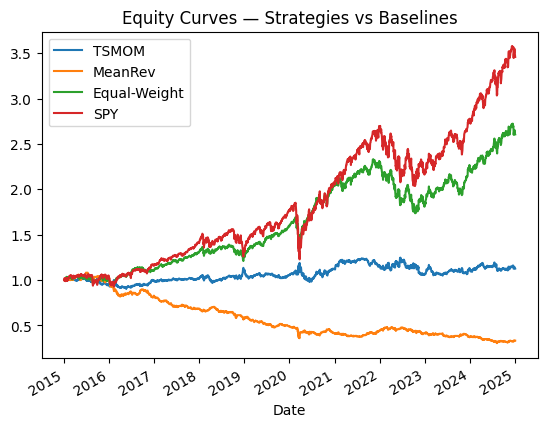

In [42]:
plt.figure()
equity_curve(rp_mom).plot(label="TSMOM")
equity_curve(rp_mr).plot(label="MeanRev")
equity_curve(rp_eq).plot(label="Equal-Weight")
equity_curve(rp_spy).plot(label="SPY")
plt.title("Equity Curves — Strategies vs Baselines")
plt.legend()
plt.show()

**Benchmark comparison.** Over 2015–2024, simple long-only baselines dominate: SPY buy-and-hold and an equal-weight ETF basket both compound strongly. In contrast, the current TSMOM implementation behaves more like a low-return, lower-drawdown overlay (limited participation in the long equity carry), while the mean-reversion specification is structurally loss-making and does not recover.

## Diagnostic: net vs gross exposure (TSMOM)

To understand why TSMOM underperforms strong long-only benchmarks in this sample, we inspect the portfolio exposure:
- **gross exposure** = sum(|w|): how much we trade / how invested we are
- **net exposure** = sum(w): directionality (long vs short bias)

In [52]:
w_used = w_mom.shift(1).fillna(0.0)

expo = pd.DataFrame({
    "net_exposure": w_used.sum(axis=1),
    "gross_exposure": w_used.abs().sum(axis=1),
})

expo.describe().round(3)

,net_exposure,gross_exposure
count,2515.000,2515.000
mean,0.298,0.976
std,0.574,0.153
min,-1.000,0.000
25%,0.000,1.000
50%,0.200,1.000
75%,0.600,1.000
max,1.000,1.000


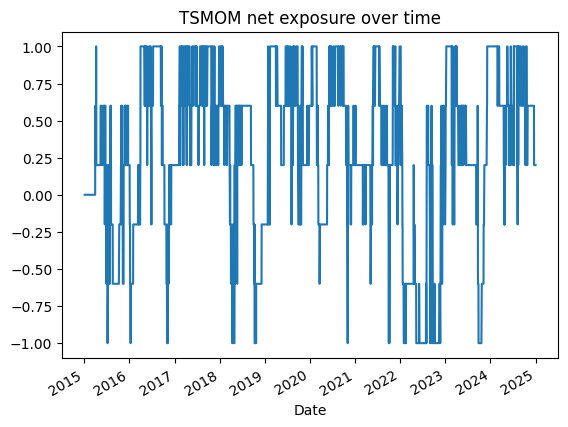

In [53]:
plt.figure()
expo["net_exposure"].plot()
plt.title("TSMOM net exposure over time")
plt.show()

Interpretation: TSMOM net exposure varies over time and can be close to neutral, which limits participation in strong long-only equity regimes and helps explain underperformance vs SPY / equal-weight benchmarks in this sample.

## 8. Sensitivity analysis (robustness)

We test how results change with:
- Lookback L ∈ {20, 60, 120}
- Costs ∈ {0, 5, 10} bps

A robust strategy should not collapse under mild costs and should not be overly tuned to one parameter.

In [50]:
rows = []
for L in [20, 60, 120]:
    for c in [0.0, 5.0, 10.0]:
        rp, w = run_strategy(rets, kind="tsmom", lookback=L, cost_bps=c)
        m = summarize_performance(rp)
        m["avg_turnover"] = float(turnover(w).mean())
        m["L"] = L
        m["cost_bps"] = c
        rows.append(m)
sens_mom = pd.DataFrame(rows).sort_values(["L", "cost_bps"])
sens_mom.round(4)

,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,L,cost_bps
0,0.0096,0.1225,0.1393,-0.2077,0.1833,20,0.0
1,-0.0134,0.1226,-0.0490,-0.2512,0.1833,20,5.0
2,-0.0359,0.1227,-0.2370,-0.3593,0.1833,20,10.0
3,0.0241,0.1175,0.2615,-0.1756,0.0957,60,0.0
4,0.0118,0.1175,0.1590,-0.1776,0.0957,60,5.0
5,-0.0003,0.1174,0.0564,-0.1796,0.0957,60,10.0
6,0.0222,0.1092,0.2557,-0.2161,0.0648,120,0.0
7,0.0139,0.1092,0.1808,-0.2248,0.0648,120,5.0
8,0.0056,0.1092,0.1060,-0.2573,0.0648,120,10.0


In [51]:
rows = []
for L in [10, 20, 40]:
    for c in [0.0, 5.0, 10.0]:
        rp, w = run_strategy(rets, kind="meanrev", lookback=L, cost_bps=c, z_entry=1.0)
        m = summarize_performance(rp)
        m["avg_turnover"] = float(turnover(w).mean())
        m["L"] = L
        m["cost_bps"] = c
        rows.append(m)
sens_mr = pd.DataFrame(rows).sort_values(["L", "cost_bps"])
sens_mr.round(4)

,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,L,cost_bps
0,0.0367,0.1443,0.3220,-0.3199,0.5883,10,0.0
1,-0.0373,0.1442,-0.1915,-0.4251,0.5883,10,5.0
2,-0.1061,0.1443,-0.7048,-0.6952,0.5883,10,10.0
3,-0.0563,0.1453,-0.3259,-0.5813,0.4213,20,0.0
4,-0.1051,0.1454,-0.6910,-0.7192,0.4213,20,5.0
5,-0.1514,0.1455,-1.0551,-0.8272,0.4213,20,10.0
6,-0.0566,0.1501,-0.3131,-0.6101,0.2829,40,0.0
7,-0.0897,0.1503,-0.5498,-0.6756,0.2829,40,5.0
8,-0.1217,0.1506,-0.7855,-0.7553,0.2829,40,10.0


## 9. Sensitivity / robustness

### TSMOM (lookback L and transaction costs)
Increasing the lookback reduces turnover materially (≈0.18 at L=20 → ≈0.10 at L=60 → ≈0.065 at L=120), which makes the strategy more resilient to trading costs. In our runs, L=60–120 yields the best (still modest) risk-adjusted performance before costs (Sharpe ≈ 0.25–0.26), while short lookbacks are highly cost-sensitive: at L=20, even 5 bps is sufficient to flip performance negative. Overall, the implementation is directionally consistent (costs hurt more when turnover is higher), but the edge remains weak relative to long-only benchmarks.

### Mean Reversion (lookback L and costs)
The mean-reversion specification is not robust in this universe. Even at 0 bps, most parameter choices exhibit negative Sharpe and large drawdowns. The only configuration with positive Sharpe (L=10, 0 bps) also has extremely high turnover (~0.59), and becomes unprofitable once realistic costs are introduced. This indicates a fragile, noise-driven signal that is dominated by frictions and adverse regime exposure.

## 10. Discussion & next steps

This decade-long sample is strongly favorable to long-only equity exposure, and simple benchmarks (SPY buy-and-hold, equal-weight ETF basket) deliver high Sharpe ratios. Against this backdrop, the current TSMOM implementation behaves like a defensive overlay: drawdowns are smaller than the baselines, but return and Sharpe are too low to compete. Sensitivity checks show that longer lookbacks reduce turnover and improve cost robustness, yet the overall edge remains modest.

The mean-reversion specification is not viable in this setting: it is unstable across parameters, often unprofitable even before costs, and dominated by turnover once realistic frictions are included. The equity/drawdown profile suggests regime mismatch (fighting trends) and noise-driven trading.

**Next iterations.**
1) Improve sizing: volatility targeting and/or risk parity across assets.  
2) Use a continuous signal (scaled trend strength) instead of binary sign exposure; consider smoothing.  
3) Add robustness: walk-forward parameter selection and simple regime filters (trend vs range) to reduce whipsaws.  

**One-line takeaway.** On this sample, long-only baselines dominate; mean reversion is invalidated; TSMOM is cost-robust but too weak without improved sizing.